In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import logging
import warnings
import pandas as pd
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import make_scorer, root_mean_squared_error


import mother.ml as ml
import mother.optimization as opt
from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

# Suppress warnings
warnings.filterwarnings("ignore")

# Ensure plots are displayed inline
%matplotlib inline
logging.basicConfig(level=logging.INFO)

### Import Data
Load the data from the input file and limit the data to 100 rows for testing purposes.
The data file contains a column with the molecular structure (__Molecule__) and a column with the target value (__expt__).



In [2]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data.head(100)  # limit data to 100 rows for testing
data = data[["iupac", "smiles", "expt"]]
data.head()

,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21


## Preprocessing
The preprocessing pipeline consists of two steps:
1. Standardize the molecular structure using the __StandardizerTransformer__.
2. Convert the standardized SMILES to a molecule object using the __SmilesToMolTransformer__.

In [3]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

mol_data.head()

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[08:14:20] Initializing Normalizer
[08:14:20] Initializing Normalizer
[08:14:20] Initializing Normalizer
[08:14:20] Initializing Normalizer
[08:14:20] Initializing MetalDisconnector
[08:14:20] Initializing Normalizer
[08:14:20] Initializing MetalDisconnector
[08:14:20] Initializing Normalizer


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x72bdd6035d90>
1,<rdkit.Chem.rdchem.Mol object at 0x72bdd60362d0>
2,<rdkit.Chem.rdchem.Mol object at 0x72bdd6035ee0>
3,<rdkit.Chem.rdchem.Mol object at 0x72bdd6037c30>
4,<rdkit.Chem.rdchem.Mol object at 0x72bdd6036340>


## Feature Generation
By combining multiple feature generators, we can create a feature matrix that contains various types of features. By default, we are combining _MACCS_ fingerprints, _Morgan_ fingerprints, and _Chemical Descriptors_.

In [4]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

features.head()

INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0


## Grouping for Cross-Validation
To ensure that the training and validation sets do not contain similar molecules, we group the molecules based on their similarity. We use the Tanimoto similarity to group molecules with a similarity threshold of 0.7. 

In [5]:
# cv grouping
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.3)

groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

cv = GroupKFold(n_splits=5)

print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.3
INFO:mother.cv.cv_methods:Found: 34 clusters
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.3
INFO:mother.cv.cv_methods:Found: 34 clusters


34 groups found


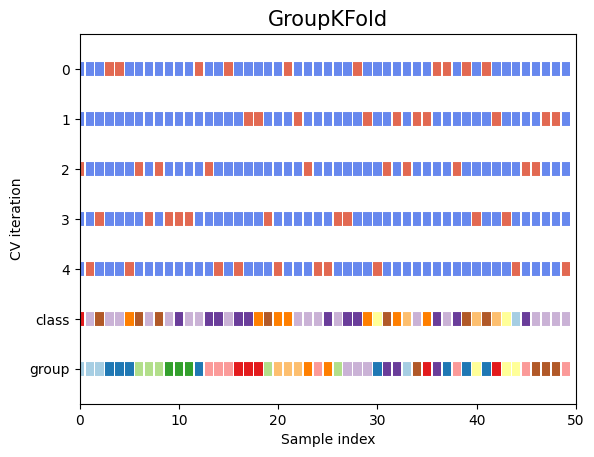

In [6]:
from mother.cv import report as cv_report

cv_report.plot_cv_indices(cv=cv, X=features, y=data["expt"], group=groups["tanimoto-group"], n_splits=5)

## Model Training
The model consists of two steps:
1. Feature selection using the __FeatureSelector__
2. Model training using the __CatboostRegressorMother__: A conventional Catboost regressor with hyperparameter tuning capabilities (used later)

In [7]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 0,
    "correlation_threshold": 0.9,
    "algorithm": "catboost",
    "feature_selection_type": "catboost",
}
pipeline_settings = {
    "remainder": "passthrough",
    "verbose_feature_names_out": False,
}
model_settings["type"] = "regression"
model_settings["target_type"] = "single_target"
model_settings["model_type"] = "regression"

model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(settings=model_settings, pipeline_settings={}).set_output(
                transform="pandas"
            ),
        ),
        ("ml_model", ml.CatboostRegressorMother(target_type="single_target", logging_level="Silent")),
    ]
)

# fit the model to data
model.fit(features, data["expt"])

targets_pred = model.predict(features)

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml:Loaded 9 model classes: RandomForestClassifierMother, RandomForestRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.ml:Loaded 9 model classes: RandomForestClassifierMother, RandomForestRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother
INFO:mother.ml.utils:Using 'RMSE' as loss function

In [8]:
# compare the predicted values with the experimental values
pd.concat((data["expt"], pd.Series(targets_pred, name="expt_pred")), axis=1).head()

,expt,expt_pred
0,-11.01,-10.799278
1,-4.87,-4.764478
2,1.83,1.747329
3,-5.45,-5.309044
4,-4.21,-4.110645


## Cross-Validation
To evaluate the model's performance, we perform cross-validation using the grouped molecules.

In [9]:
data["expt"]

0    -11.01
1     -4.87
2      1.83
3     -5.45
4     -4.21
5     -6.27
6      2.34
7     -3.92
8      1.58
9     -4.62
10    -1.96
11    -3.88
12    -4.33
13    -2.49
14    -2.55
15    -4.78
16    -1.46
17    -2.22
18    -5.85
19     2.88
20    -6.34
21    -6.10
22    -5.48
23    -4.10
24    -4.10
25    -3.52
26    -4.47
27    -2.74
28    -3.43
29    -7.81
30    -0.80
31     0.93
32    -6.78
33    -9.29
34    -4.07
35    -5.91
36    -2.13
37    -3.64
38    -2.68
39     3.13
40   -10.00
41     2.06
42    -8.11
43    -1.12
44   -23.62
45    -2.83
46    -4.68
47    -5.56
48    -3.65
49    -5.49
Name: expt, dtype: float64

In [10]:
cross_val_scores: pd.DataFrame = mother_takes_care.mother_cv(
    estimator=model, X=features, y=data["expt"], groups=groups["tanimoto-group"], cv=cv
)
cross_val_scores.head()

INFO:mother.pipeline_utils:Starting cross validation...
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature impo

,pred_expt,pred_knowledge_uncertainty,expt,cv_group,iteration,test_index
0,-6.321559,0.004106,-11.01,0,2,0
1,-3.839761,0.00083,-4.87,1,4,1
2,0.074111,0.00234,1.83,2,3,2
3,-3.501542,0.000225,-5.45,3,0,3
4,-4.566199,0.000929,-4.21,4,0,4


## Hyperparameter Optimization
To optimize the hyperparameters of the model, we use the __MotherTuner__. The tuner uses the models own __get_hyperparameter_space__ function to define the hyperparams, theirs bounds and transformations. If needed, this function can be overwritten to define custom hyperparameters.

The cross-val splits are used for the hyperparameter optimization. After the optimization, the model is retrained on the whole dataset.


In [11]:
model

PipelineWithHyperparameterRooting(steps=[('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(transformers=[('feature_selector',
                                                                                                    PipelineWithHyperparameterRooting(steps=[('duplicate_selector',
                                                                                                                                              DropDuplicateFeatures()),
                                                                                                                                             ('constant_selector',
                                                                                                                                              DropConstantFeatures(missing_values='ignore')),
                                                                                                                                             ('correlation_selector',
                                                                                                                                              SmartCorrelatedSelection(selection_method='variance',
                                                                                                                                                                       threshold=0.9)),
                                                                                                                                             ('importance_selector',
                                                                                                                                              MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72be369bf510>,
                                                                                                                                                                                                       max_depth=6),
                                                                                                                                                                    threshold=0))]),
                                                                                                    <function get_numeric_columns at 0x72bdde70ea20>)])),
                                         ('ml_model',
                                          <mother.ml.models.m_catboost.CatboostRegressorMother object at 0x72bdcd2aad10>)])

In [12]:
scorer = make_scorer(score_func=root_mean_squared_error, greater_is_better=False)

# n_threads_optuna is the number of parallel threads for hyperparameter optimization
# so it should not be higher then the number of cross-validation folds
tuner = opt.MotherTuner(
    n_threads_optuna=5,
    scorer=scorer,
    n_trials_optuna=1,
    n_startup_trials=1,
    tuning_direction="maximize",
)


model_tuned = tuner.optimize(
    model,
    features,
    data["expt"],
    cv,
    hyperparameter_space_function=model.get_hyperparameter_space,
    default_parameters=model.default_parameters(),
    groups=groups["tanimoto-group"].values,
)

INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-5633d01f-0b61-45ed-92c1-1864cd74b9d4
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
INFO:mother.ml.utils:Calculating tree depth range based on the number of rows in the data frame
INFO:mother.ml.models.m_catboost:Suggested parameters in trial 0: {'ml_model__bootstrap_type': 'Bayesian', 'ml_model__learning_rate': 0.03, 'ml_model__random_strength': 1, 'ml_model__grow_policy': 'SymmetricTree', 'ml_model__boosting_type': 'Plain', 'ml_model__max_depth': 6, 'ml_model__loss_function': 'RMSE'}
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-5633d01f-0b61-45ed-92c1-1864cd74b9d4
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
INFO:mother.ml.utils:Calculating tree depth range based on the number of rows in the data frame


{'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__bootstrap_type': 'Bayesian', 'ml_model__learning_rate': 0.03, 'ml_model__random_strength': 1.0, 'ml_model__grow_policy': 'SymmetricTree', 'ml_model__boosting_type': 'Plain', 'ml_model__max_depth': 6, 'ml_model__loss_function': 'RMSE'}


INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.optimization.core:Training completed
INFO:mother.optimization.core:Training completed


In [13]:
targets_pred = model_tuned.predict(features)
pd.concat((data["expt"], pd.Series(targets_pred, name="expt_pred")), axis=1).head()

,expt,expt_pred
0,-11.01,-10.797363
1,-4.87,-4.761253
2,1.83,1.745490
3,-5.45,-5.315041
4,-4.21,-4.106825


## Hyperparameter Optimization with nested CV
When we optimize the hyperparameters, we use a cross validation approach. Based on performance in the cross validations we choose the best set of hyperparameters. The selection of the best hyperparameters is based on the full data, so we do not really evaluate the tuning process itself. 

To properly evaluate the performance of the tuning we need to include the hyperparameter tuning in the evaluation too. 

For this we make use of a nested cross validation.

In [14]:
# make an outer cv split to be used for the outer cross validation
cv_outer = KFold(n_splits=2, random_state=42, shuffle=True)

# now run the nested cross validation with tuning in the inner fold
cv_table: pd.DataFrame = mother_takes_care.mother_cv(
    model,
    tuner=tuner,
    inner_cv=cv,
    cv=cv_outer,
    groups=groups["tanimoto-group"],
    X=features,
    y=data["expt"],
)
cv_table.head()

INFO:mother.pipeline_utils:Starting cross validation...
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-9b68aeb7-5f71-43cf-b0c4-cf981e0bd33a
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
INFO:mother.ml.utils:Calculating tree depth range based on the number of rows in the data frame
INFO:mother.ml.models.m_catboost:Suggested parameters in trial 0: {'ml_model__bootstrap_type': 'Bayesian', 'ml_model__learning_rate': 0.03, 'ml_model__random_strength': 1, 'ml_model__grow_policy': 'SymmetricTree', 'ml_model__boosting_type': 'Plain', 'ml_model__max_depth': 6, 'ml_model__loss_function': 'RMSE'}
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-9b68aeb7-5f71-43cf-b0c4-cf981e0bd33a
INFO:mother.optimiz

{'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__bootstrap_type': 'Bayesian', 'ml_model__learning_rate': 0.03, 'ml_model__random_strength': 1.0, 'ml_model__grow_policy': 'SymmetricTree', 'ml_model__boosting_type': 'Plain', 'ml_model__max_depth': 6, 'ml_model__loss_function': 'RMSE'}


INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.optimization.core:Training completed
INFO:mother.optimization.core:Training completed
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-89f6d15b-046a-464c-848f-ea0442dafcfd
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
INFO:mother.ml.utils:Calculating tree depth range based on the number of rows in the data frame
INFO:mother.ml.models.m_catboost:Suggested paramete

{'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'ml_model__bootstrap_type': 'Bayesian', 'ml_model__learning_rate': 0.03, 'ml_model__random_strength': 1.0, 'ml_model__grow_policy': 'SymmetricTree', 'ml_model__boosting_type': 'Plain', 'ml_model__max_depth': 6, 'ml_model__loss_function': 'RMSE'}


INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.optimization.core:Training completed
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction
INFO:mother.optimization.core:Training completed
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction
INFO:mother.pipeline_utils:Cross validation completed
INFO:mother.pipeline_utils:Cross validation completed


,pred_expt,pred_knowledge_uncertainty,expt,cv_group,iteration,test_index
0,-3.608549,0.000158,-11.01,0,1,0
1,-3.175982,0.001538,-4.87,1,1,1
2,0.505779,0.000163,1.83,2,1,2
3,-3.608009,0.019473,-5.45,3,0,3
4,-4.267788,0.003834,-4.21,4,0,4
